# Machine Learning model to predict LTV of a customer

the expected future value of our current customer base over a three-month period. Developed using transactional data from a UK-based e-commerce store, the model employs a two-stage regression approach:

    Churn Prediction (Logistic Regression): It first determines the probability of a customer churning within the three-month window.

    Future Spend Prediction (Linear Regression): For customers predicted to remain active, it forecasts their total spending over the same period.
    
Currently, the model utilizes RFM (Recency, Frequency, Monetary) features for its predictions. I plan to expand the feature set after the initial model is deployed. This model could enable a marketing team to identify high-value customers at risk of churn and to forecast future revenue from our existing customer base.


# Loading data 
The data transactional data use is from 01/12/2010 and 09/12/2011 and it is from a UK-based and registered non-store online retail.The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split


In [5]:
transactions = pd.read_csv('Ecommerce_data.csv', encoding='latin')
transactions.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 8:26,3.39,17850.0,United Kingdom


# Data Exploration / Analysis and correction of errors

In [6]:
transactions.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [7]:
# taking out any incorrect data entry
transactions=transactions.loc[transactions['UnitPrice']>0]
transactions=transactions.loc[transactions['Quantity']>0]


In [8]:
# formatting the date column
transactions['InvoiceDate']=pd.to_datetime(transactions['InvoiceDate'])
transactions['month'] = transactions['InvoiceDate'].dt.month
transactions['year'] = transactions['InvoiceDate'].dt.year
transactions.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,month,year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010


In [9]:
# Roughly a years worth of data has been gathered
transactions['InvoiceDate']=pd.to_datetime(transactions['InvoiceDate'])
print(transactions['InvoiceDate'].min())
print(transactions['InvoiceDate'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


## Sales were around the 700-800k for January - August and then increase to 1 million for September to December 

         Date  month  year        Sales
0  2010-12-01     12  2010   823746.140
1  2011-01-01      1  2011   691364.560
2  2011-02-01      2  2011   523631.890
3  2011-03-01      3  2011   717639.360
4  2011-04-01      4  2011   537808.621
5  2011-05-01      5  2011   770536.020
6  2011-06-01      6  2011   761739.900
7  2011-07-01      7  2011   719221.191
8  2011-08-01      8  2011   759138.380
9  2011-09-01      9  2011  1058590.172
10 2011-10-01     10  2011  1154979.300
11 2011-11-01     11  2011  1509496.330
12 2011-12-01     12  2011   638792.680


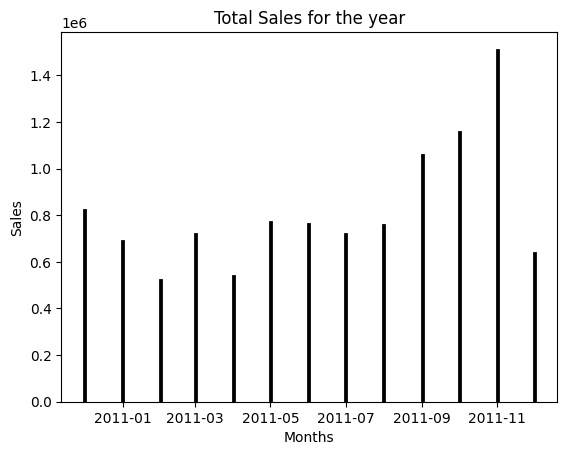

In [10]:
# Sales accross the year
transactions['Sales']=transactions['Quantity']*transactions['UnitPrice']

total_monthly_sales=transactions.groupby(['month','year']).agg({'Sales':'sum'})
total_monthly_sales=total_monthly_sales.reset_index()
total_monthly_sales['Date'] = pd.to_datetime(total_monthly_sales[['year', 'month']].assign(day=1))
total_monthly_sales=total_monthly_sales.groupby(['Date']).agg('sum').reset_index()

sum_monthly_sales=total_monthly_sales[['Sales','Date']]
print(total_monthly_sales)


plt.bar(sum_monthly_sales['Date'],sum_monthly_sales['Sales'],linewidth=2.0,edgecolor='black')
plt.title('Total Sales for the year')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.show()

# Customers
## There are 4338 unique customers and a total of 397884 transactions with Customer IDs and 132220 without CustomerID. There are a total of 530,104 transactions


In [11]:
print(transactions['CustomerID'].nunique())
print(transactions['CustomerID'].count())
print((transactions['CustomerID'].isnull()).count())

4338
397884
530104


In [12]:
transactions

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,month,year,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2010,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2010,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,12,2011,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12,2011,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,12,2011,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,12,2011,16.60


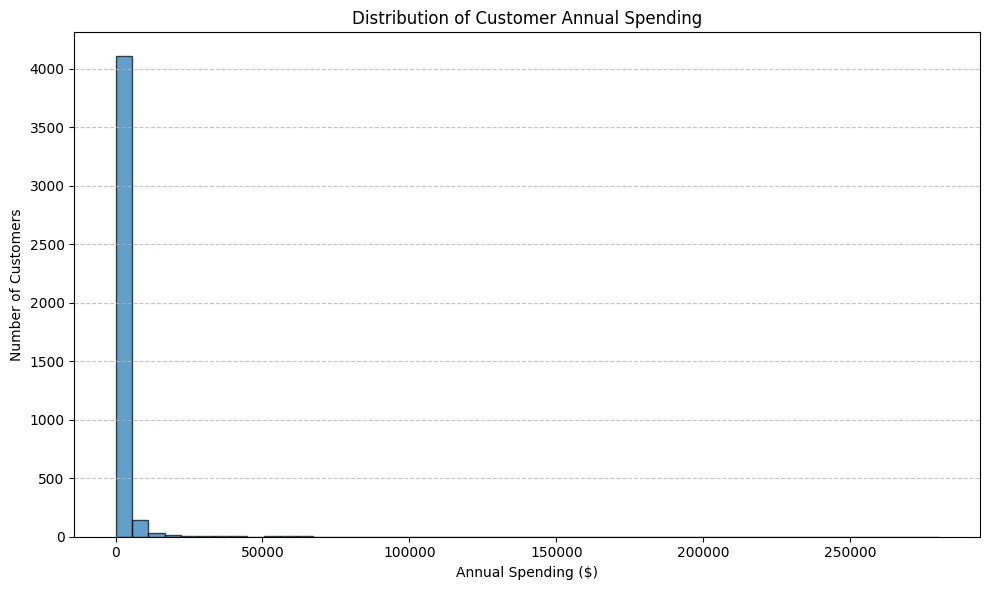

In [13]:
cust_trans=transactions[['Sales','CustomerID']].groupby(['CustomerID']).agg('sum').sort_values('Sales')
# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(cust_trans, bins=50, edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel('Annual Spending ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Annual Spending')

# Add grid for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')

plt.tight_layout()
plt.show()

In [14]:
transactions=transactions.loc[transactions['Sales']<10000]

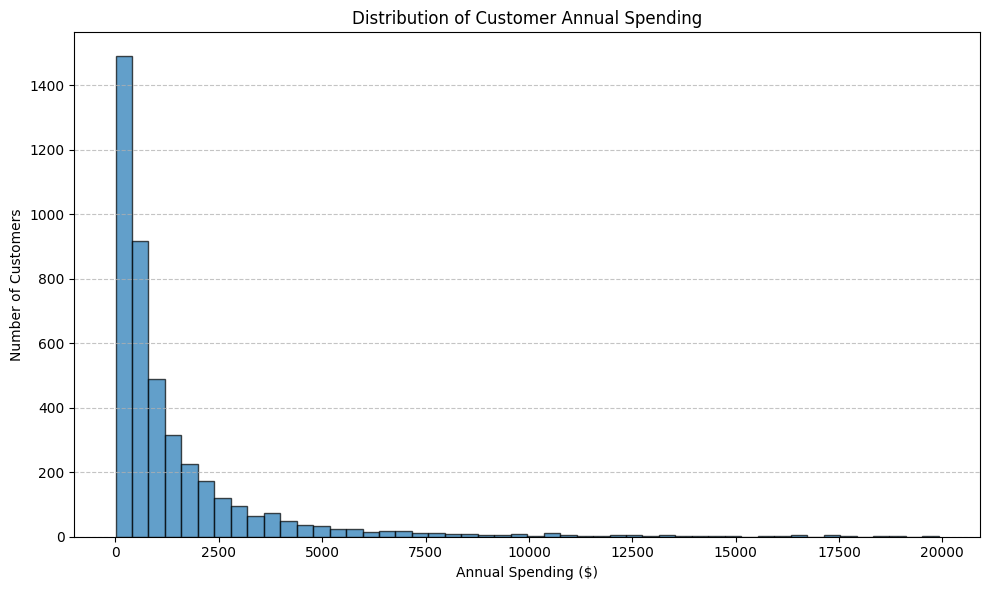

In [15]:


# cust_trans=cust_trans.reset_index()
cust_spec=cust_trans.loc[cust_trans['Sales']<20000]
# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(cust_spec, bins=50, edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel('Annual Spending ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Annual Spending')

# Add grid for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')

plt.tight_layout()
plt.show()

In [16]:
# Item quantity sold
# largest quantity of items sold
item_quant=transactions.groupby(['Description']).agg({'Quantity':'sum'}).reset_index()
item_quant=item_quant.sort_values('Quantity')
top_sales=item_quant.tail(10)
print(top_sales)

                             Description  Quantity
2334  PACK OF 60 PINK PAISLEY CAKE CASES     24854
2302          PACK OF 12 LONDON TISSUES      26135
2106             MINI PAINT SET VINTAGE      26633
2739                  RABBIT NIGHT LIGHT     30788
2336     PACK OF 72 RETROSPOT CAKE CASES     36419
227        ASSORTED COLOUR BIRD ORNAMENT     36461
2679                      POPCORN HOLDER     36761
3842  WHITE HANGING HEART T-LIGHT HOLDER     37891
1815             JUMBO BAG RED RETROSPOT     48474
3932   WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047


# The Vast majority of transactions come from UK (91.5%)

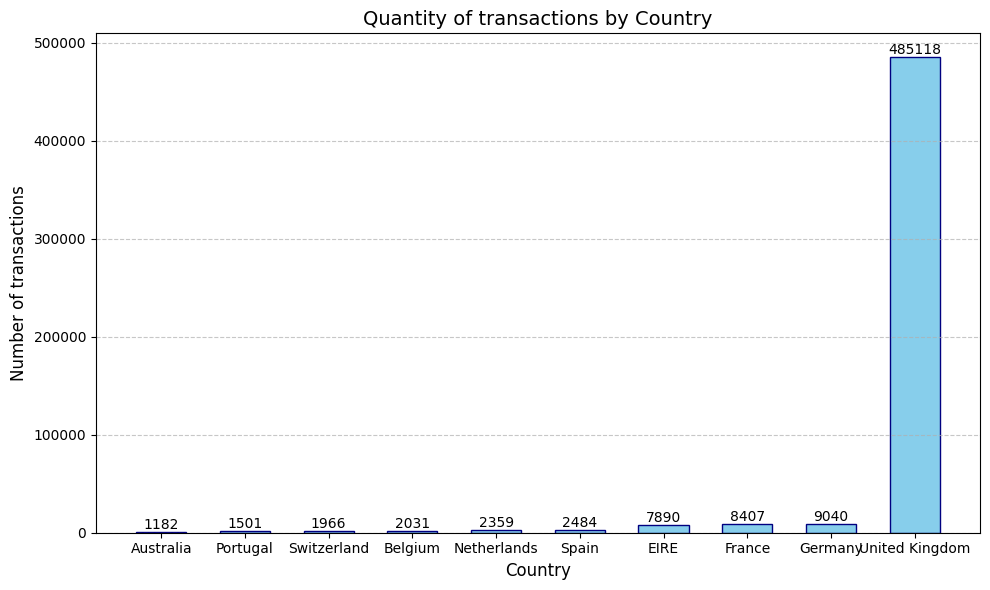

In [17]:
trans_by_country=transactions.groupby(['Country']).agg({'Country':'count'})
trans_by_country=trans_by_country.rename(columns={'Country':'Quantity'})
trans_ranks_count=trans_by_country.sort_values('Quantity').tail(10).reset_index()


plt.figure(figsize=(10, 6))
bars = plt.bar(height=trans_ranks_count['Quantity'],x=trans_ranks_count['Country'], color='skyblue', edgecolor='navy', width=0.6)

# Add title and labels
plt.title('Quantity of transactions by Country', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of transactions', fontsize=12)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height}', ha='center', va='bottom')

# Add grid lines for the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Customize appearance
plt.tight_layout()
plt.show()

# Using the ML algorithm to understand the expected LTV of customers

Lifetime Value of customers is the future value of the customer, which can be seperated into

- will they Churn? (Classification)
 
- what is the expected customer spend of the customer? (Regression)

2 different models will be used to predict whether they will churn and what will be the value of there spend. This knowledge will be used to prioritise marketing spend into "saving customers", allowing promotional spend to be less then the expected future spend of customers.

# Step 1 - Defining the problems and the parameters of the model
a) Define Churn:
We will define churn as a customer not having purchased a good for 90 days

b) Seperate the historical (Training Data) and the testing data as to be able to quantify the accuracy of the model






In [18]:
n_days = 90
max_date=transactions['InvoiceDate'].max()
cutoff= max_date-pd.to_timedelta(n_days, unit="d")
 # train-test Split- temporal out df relates to the actual amount of expenditure in the next 90 days after the target date
print(cutoff)

2011-09-10 12:50:00


## Develop targets: To compare the actual vs the predicted
Filtering the out data for customers who only exist in the in data

In [19]:
temporal_in_df=transactions[transactions['InvoiceDate']< cutoff]
temporal_out_df=transactions[transactions['InvoiceDate'] >=cutoff].query('CustomerID in @temporal_in_df.CustomerID')
targets=temporal_out_df[['CustomerID','Sales']].groupby(['CustomerID']).sum().rename({'Sales':'Sales_90'},axis=1).assign(sales_90_flag=1)

In [20]:
max_date=temporal_in_df['InvoiceDate'].max()
recency_features_df=temporal_in_df[['CustomerID','InvoiceDate']].groupby('CustomerID').apply(lambda x: int((x['InvoiceDate'].max()-max_date)/pd.to_timedelta(1,"day"))).to_frame()
recency_features_df=recency_features_df.rename(columns={0:'Recency'})
recency_features_df.head()

C:\Users\As-Pro\AppData\Local\Temp\ipykernel_2148\2772036709.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recency_features_df=temporal_in_df[['CustomerID','InvoiceDate']].groupby('CustomerID').apply(lambda x: int((x['InvoiceDate'].max()-max_date)/pd.to_timedelta(1,"day"))).to_frame()


,Recency
CustomerID,
12347.0,-38
12348.0,-157
12350.0,-219
12352.0,-171
12353.0,-113


# Step 2: Create  Features which represent the RFM analysis as the basis for the ML model
Recency- when was the last time they made a purchase

Frequency- How many times did they purchase during the period

Monetary Values- What was the total monetary value they spent during the time and what is the average value of the the transactions

As RFM have known relationships between the future value of a customer we will use this as the basis for the ML. In the future we can develop further features which increase the relationship between historical data and the future value.

## Create Recency Features
- The last time they purchased minus the maximum amount of days during the period under analysis

max_date=temporal_in_df['InvoiceDate'].max()
recency_features_df=temporal_in_df[['CustomerID','InvoiceDate']].groupby('CustomerID').apply(lambda x: int((x['InvoiceDate'].max()-max_date)/pd.to_timedelta(1,"day"))).to_frame()
recency_features_df=recency_features_df.rename(columns={0:'Recency'})
recency_features_df.head()

In [21]:
recency_features_df

,Recency
CustomerID,
12347.0,-38
12348.0,-157
12350.0,-219
12352.0,-171
12353.0,-113
...,...
18280.0,-186
18281.0,-89
18282.0,-35


# Majority of customers ordered less than a year ago

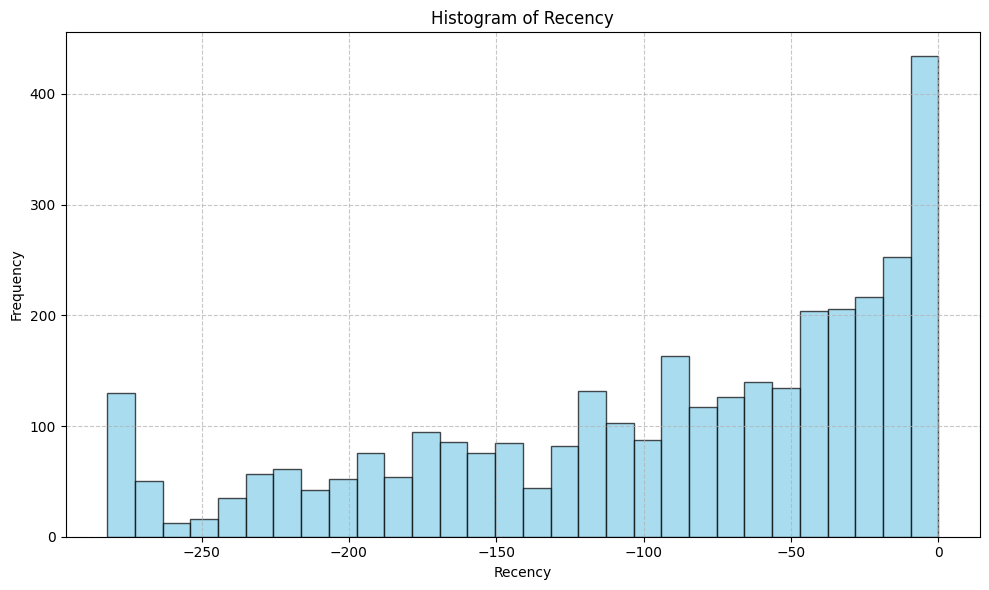

In [22]:
column_name = 'Recency'  # Replace with your actual column name

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(recency_features_df[column_name], bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel(column_name)
plt.ylabel('Frequency')
plt.title(f'Histogram of {column_name}')

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

# Create Frequency Features
- The number of times in which they purchased over the period under analysis

In [23]:
frequency_features_df=temporal_in_df[['CustomerID','InvoiceDate']].groupby('CustomerID').count()
frequency_features_df=frequency_features_df.rename(columns={'InvoiceDate':'Frequency'})
frequency_features_df.head()

,Frequency
CustomerID,
12347.0,124
12348.0,28
12350.0,17
12352.0,38
12353.0,4


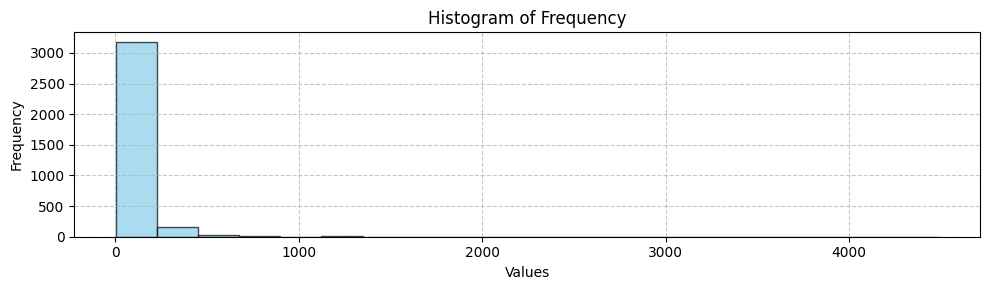

In [24]:
# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=len(frequency_features_df.columns), figsize=(10, 3*len(frequency_features_df.columns)))

# If there's only one column, axes will not be an array
if len(frequency_features_df.columns) == 1:
    axes = [axes]

# Plot histogram for each column
for i, column in enumerate(frequency_features_df.columns):
    axes[i].hist(frequency_features_df[column], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel('Values')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [25]:
frequency_features_df[frequency_features_df['Frequency']>1500]


,Frequency
CustomerID,
12748.0,2040
14606.0,2038
14911.0,2958
15311.0,1725
17841.0,4490


In [26]:
frequency_features_df[frequency_features_df['Frequency']>1500]

,Frequency
CustomerID,
12748.0,2040
14606.0,2038
14911.0,2958
15311.0,1725
17841.0,4490


# Create Monetary Value Features
- The average sale of each transactions and the total sales during the period of historical sales


In [27]:
monetary_features=temporal_in_df.groupby(['CustomerID']).agg({'Sales':['sum','mean']}).set_axis(['sales_value_sum','sales_values_mean'],axis=1)
print(monetary_features)

            sales_value_sum  sales_values_mean
CustomerID                                    
12347.0             2790.86          22.506935
12348.0             1487.24          53.115714
12350.0              334.40          19.670588
12352.0             1561.81          41.100263
12353.0               89.00          22.250000
...                     ...                ...
18280.0              180.60          18.060000
18281.0               80.82          11.545714
18282.0              100.21          14.315714
18283.0             1120.67           2.507092
18287.0              765.28          26.388966

[3369 rows x 2 columns]


In [28]:
monetary_features

,sales_value_sum,sales_values_mean
CustomerID,,
12347.0,2790.86,22.506935
12348.0,1487.24,53.115714
12350.0,334.40,19.670588
12352.0,1561.81,41.100263
12353.0,89.00,22.250000
...,...,...
18280.0,180.60,18.060000
18281.0,80.82,11.545714
18282.0,100.21,14.315714


# Create A month off Cutoff as a feature
This will be an added feature which will help develop the future probability of LTV. As a customer who has purchased within the last 14 days, is a greater 

In [29]:
cut_off_m= cutoff-pd.to_timedelta(30,unit="d")

sales_last_month=temporal_in_df.query('InvoiceDate >= @cut_off_m')\
[['CustomerID','Sales']].drop_duplicates()\
.groupby('CustomerID')\
.sum()\
.set_axis(['sales_last_month'],axis=1).fillna(0)


array([[<Axes: title={'center': 'sales_last_month'}>]], dtype=object)

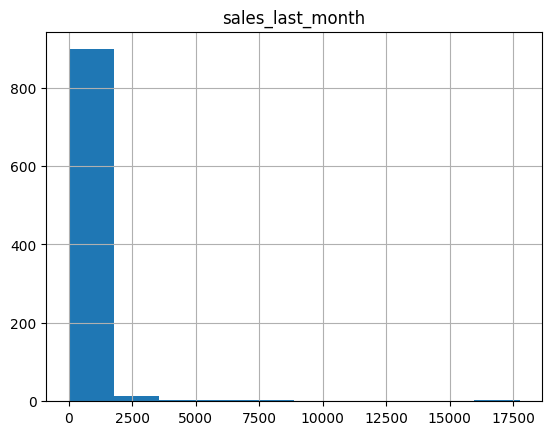

In [30]:
sales_last_month.hist()

# Concatinate all the features into the singular dataframe and merge in the targets

In [31]:
features=pd.concat([recency_features_df, frequency_features_df, monetary_features,sales_last_month],axis=1)
features['sales_last_month']=features['sales_last_month'].fillna(0)
features=features.merge(targets,how='left',left_index=True,right_index=True)
features['Sales_90']=features['Sales_90'].fillna(0)
features['sales_90_flag']=features['sales_90_flag'].fillna(0)
features.head()

,Recency,Frequency,sales_value_sum,sales_values_mean,sales_last_month,Sales_90,sales_90_flag
CustomerID,,,,,,,
12347.0,-38,124,2790.86,22.506935,0.0,1519.14,1.0
12348.0,-157,28,1487.24,53.115714,0.0,310.00,1.0
12350.0,-219,17,334.40,19.670588,0.0,0.00,0.0
12352.0,-171,38,1561.81,41.100263,0.0,944.23,1.0
12353.0,-113,4,89.00,22.250000,0.0,0.00,0.0


# Regression model to predict the value of a customer

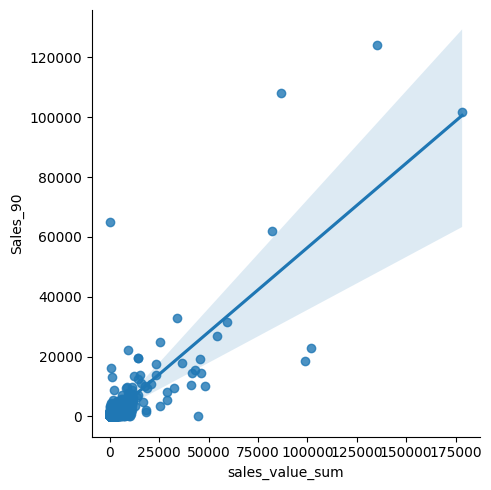

In [32]:

sns.lmplot(x='sales_value_sum',y='Sales_90',data=features)
plt.show()


The hypothesis is that customers who have a greater recency in there last purchase will have a higher probability of not churning, as there will be a lower chance of external factors effecting customers demand for product such as bankruptcy change, change of catalogu or changing supplier

The Boxplot shows that those customers who didnt churn (made a purchase in the last 90 days) had made a purchase on average more recently then those who did churn. This is an indicator that recency is a good indicator for whether a customer more will churn or not. This is furthered by the one way ANOVA test with a p-value of pretty much zero, indicating a strong relationship between the average recency and whether they have churned or not

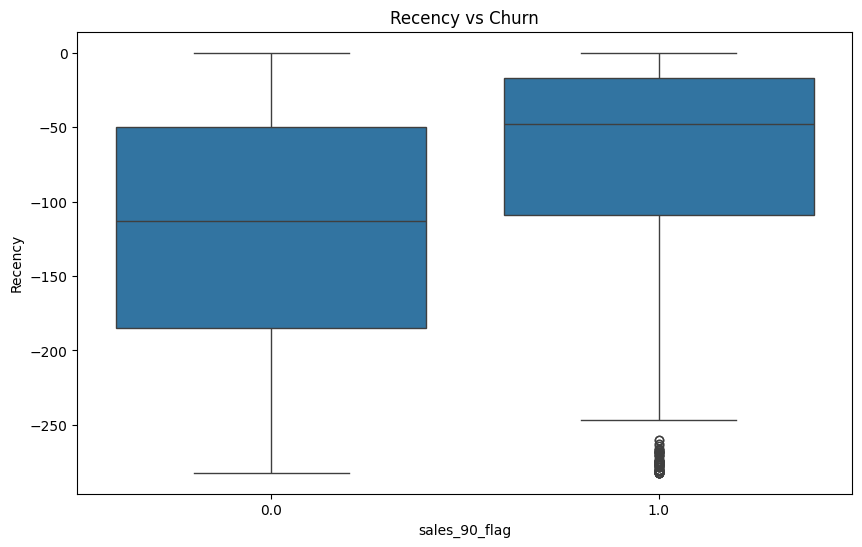

In [33]:

# Create box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='sales_90_flag', y='Recency', data=features)
plt.title('Recency vs Churn')
plt.show()

In [34]:
import scipy.stats as stats 

In [35]:
features.head()

,Recency,Frequency,sales_value_sum,sales_values_mean,sales_last_month,Sales_90,sales_90_flag
CustomerID,,,,,,,
12347.0,-38,124,2790.86,22.506935,0.0,1519.14,1.0
12348.0,-157,28,1487.24,53.115714,0.0,310.00,1.0
12350.0,-219,17,334.40,19.670588,0.0,0.00,0.0
12352.0,-171,38,1561.81,41.100263,0.0,944.23,1.0
12353.0,-113,4,89.00,22.250000,0.0,0.00,0.0


In [36]:
# Assuming df has your data with 'category_col' and 'continuous_col'
categories = features['sales_90_flag'].unique()
data_by_category = [features[features['sales_90_flag'] == cat]['Recency'] for cat in categories]

# One-way ANOVA
f_stat, p_value = stats.f_oneway(*data_by_category)
print(f"F-statistic: {f_stat}, p-value: {p_value}")

F-statistic: 345.745224339899, p-value: 1.529374578448938e-73


Testing the relationship between frequency and churn. With the hypthosis of greater frequency forming more of a habit and a greater dependency on the supplier. 

The boxplot below shows customer who havent churned have a higher median frequency then those that have churned. The p-value of the Frequency and the 90 day chis very low as well, which means there is a very high probability that the frequency and feature are related.

In [37]:
# Assuming df has your data with 'category_col' and 'continuous_col'
categories = features['sales_90_flag'].unique()
data_by_category = [features[features['sales_90_flag'] == cat]['Frequency'] for cat in categories]

# One-way ANOVA
f_stat, p_value = stats.f_oneway(*data_by_category)
print(f"F-statistic: {f_stat}, p-value: {p_value}")

F-statistic: 164.45847006933926, p-value: 8.603762648546917e-37


## Splitting the features data set into training and testing data with 20-80 split

In [40]:
x=features.drop(columns=['Sales_90','sales_90_flag'])
y=features[['Sales_90']]


x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=100,test_size=.2)

### NMSE is calculated as the ratio of the MSE to the variance of the observed data.

In [41]:


model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)


mse = metrics.mean_squared_error(y_test, y_pred)

# Calculate variance of true values
variance = np.var(y_test)

# Normalized MSE
nmse = mse / variance

print(nmse)


NameError: name 'LinearRegression' is not defined

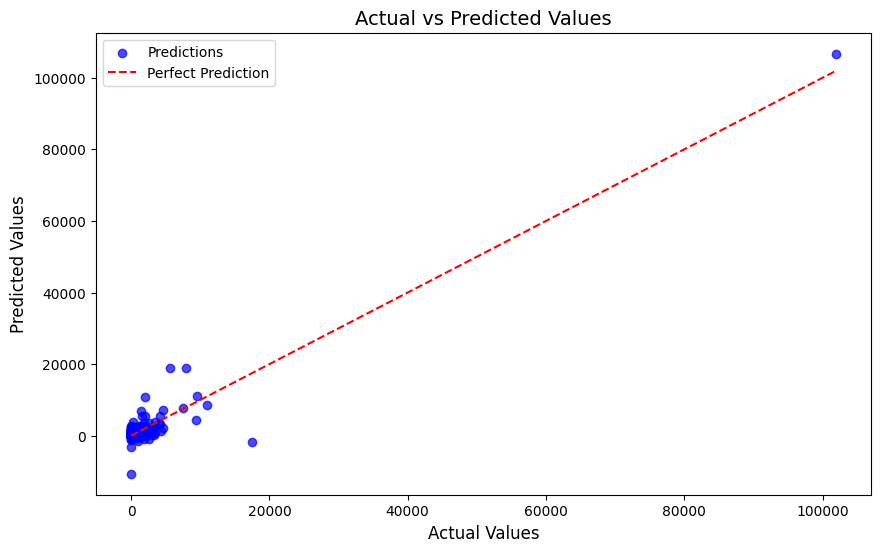

In [ ]:
# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', label='Predictions')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', 
         linestyle='--', 
         label='Perfect Prediction')

# Plot styling
plt.title('Actual vs Predicted Values', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()

# The Gradient Booster had a 

In [ ]:
# model = GradientBoostingRegressor(n_estimators=100)

# model.fit(x_train, y_train)


# y_pred = model.predict(x_test)

# # Evaluate the model's performance
# mse = mean_squared_error(y_test, y_pred)
# print(f"Mean Squared Error: {mse}")

# # Example of accessing feature importances
# feature_importances = model.feature_importances_
# print("Feature Importances:", feature_importances)

# y_pred = model.predict(x_test)
# # print( accuracy_score(y_test, y_pred))
# # print(classification_report(y_test, y_pred))

C:\Users\As-Pro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Mean Squared Error: 10725835.371993471
Feature Importances: [0.02045403 0.13372032 0.6863831  0.14330422 0.01613833]


In [ ]:
import sklearn.metrics as metrics

# Logistical regression for the classification of of Churn, not Churn 

In [ ]:
x=features.drop(columns=['Sales_90','sales_90_flag'])
i=features[['sales_90_flag']]



i_train,i_test,y_train,y_test=train_test_split(i,x,random_state=100,test_size=.2)

print(i.shape)
print(x.shape)

(3369, 1)
(3369, 6)


In [ ]:
features

,Recency,Frequency,sales_value_sum,sales_values_mean,sales_last_month,Sales_90,sales_90_flag,sales_total_value
CustomerID,,,,,,,,
12347.0,-38,124,2790.86,22.506935,0.00,1519.14,1.0,2790.86
12348.0,-157,28,1487.24,53.115714,0.00,310.00,1.0,1487.24
12350.0,-219,17,334.40,19.670588,0.00,0.00,0.0,334.40
12352.0,-171,38,1561.81,41.100263,0.00,944.23,1.0,1561.81
12353.0,-113,4,89.00,22.250000,0.00,0.00,0.0,89.00
...,...,...,...,...,...,...,...,...
18280.0,-186,10,180.60,18.060000,0.00,0.00,0.0,180.60
18281.0,-89,7,80.82,11.545714,0.00,0.00,0.0,80.82
18282.0,-35,7,100.21,14.315714,0.00,77.84,1.0,100.21


In [ ]:
x_train

,Recency,Frequency,sales_value_sum,sales_values_mean,sales_last_month,sales_total_value
CustomerID,,,,,,
16824.0,-73,13,222.90,17.146154,0.00,222.90
16212.0,-192,30,498.15,16.605000,0.00,498.15
17063.0,-72,38,671.87,17.680789,0.00,671.87
17110.0,-74,12,163.30,13.608333,0.00,163.30
15121.0,-197,18,295.15,16.397222,0.00,295.15
...,...,...,...,...,...,...
15690.0,-9,8,111.00,13.875000,103.92,111.00
12465.0,-78,26,440.94,16.959231,0.00,440.94
15561.0,-58,16,449.67,28.104375,0.00,449.67


C:\Users\As-Pro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000)

Accuracy: 0.6706231454005934
              precision    recall  f1-score   support

         0.0       0.63      0.57      0.60       290
         1.0       0.70      0.75      0.72       384

    accuracy                           0.67       674
   macro avg       0.66      0.66      0.66       674
weighted avg       0.67      0.67      0.67       674



# Regression model for the predictions of the monetary value spent by the customer over the 90 days

In [ ]:
reg_setup=reg.setup(
    data=features.drop('sales_90_flag',axis=1),
    target='Sales_90',
    train_size=.8,
    normalize=True,
    session_id=123,
    verbose=True,
    log_experiment=False
)


NameError: name 'reg' is not defined

In [ ]:
compare_models

# Evaluating the model
MAE: Mean absolute errors, the sum of all the errors (all positives) 
RMSE: The square of all the errors and takes there mean. Increasing the importance of larger error rates and then getting the squared root of the final amount 
R squared: How much the real values differ from the estimates, closer to one the better


In [ ]:

xgb_reg_model=reg.create_model('xgboost')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,429.0400,711343.4375,843.4118,-0.4381,3.3603,1.3919
1,528.6376,1740855.7500,1319.4149,0.3968,3.9031,4.5209
2,786.7193,9826901.0000,3134.7888,-0.6877,3.8840,21.0573
3,610.6152,2576537.2500,1605.1595,0.1884,3.5449,1.2339
4,951.2869,35231660.0000,5935.6265,-16.1770,3.8304,1.1327
5,908.1991,23477892.0000,4845.3989,0.4740,3.7160,1.1663
6,1144.8636,106449416.0000,10317.4326,-0.0111,3.8038,0.7804
7,1201.6812,47972640.0000,6926.2285,0.3662,3.3409,0.8986
8,534.3530,2887387.2500,1699.2313,0.9342,3.5500,0.6330


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
xgb_reg_model

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cpu', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
reg_prediction_df=reg.predict_model(xgb_reg_model,data= features)\
.sort_values('prediction_label',ascending=False)


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,292.3905,2986112.2500,1728.0372,0.8809,3.2164,0.6168


In [ ]:
tuned_xgb=tune_model('reg_prediction_df')

TypeError: The behavior of tune_model in version 1.0.1 is changed. Please pass trained model object.

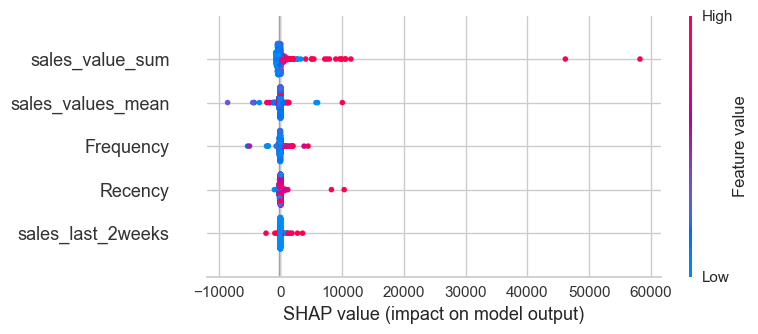

In [ ]:
reg.interpret_model(xgb_reg_model)

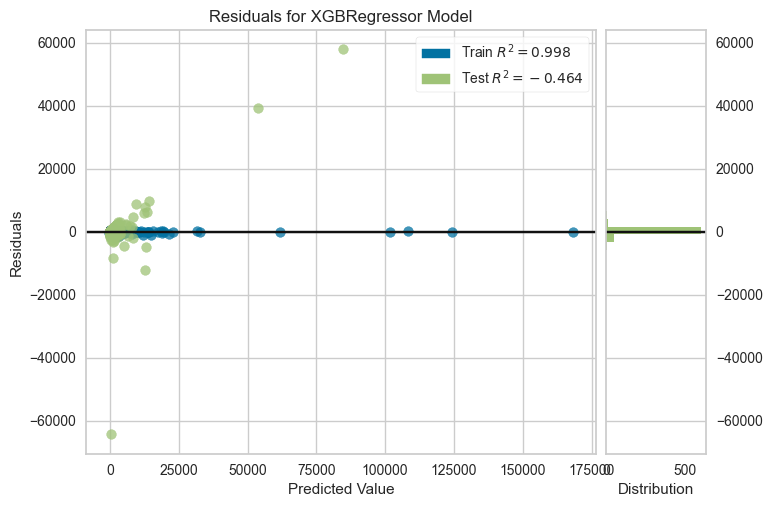

In [ ]:
plot_model(xgb_reg_model)

# Classification model on whether they churn or not over the 90 days

In [ ]:

# Classification (spend probability)
# have to drop the sales_90_value as that is a precursor to the classification problem of whether they spend or not
clf_setup=clf.setup(
    data=features.drop('Sales_90',axis=1),
    target='sales_90_flag',
    train_size=.8,
    normalize=True,
    verbose=True,
    log_experiment=False
                    )




,Description,Value
0,Session id,405
1,Target,sales_90_flag
2,Target type,Binary
3,Original data shape,"(3370, 6)"
4,Transformed data shape,"(3370, 6)"
5,Transformed train set shape,"(2696, 6)"
6,Transformed test set shape,"(674, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,simple


## Evaluation of classification ML models
Precision: % of correctly labelled positive instance out of all positive labelled instances TP/TP+FP

Recall: % of correctly labelled positives instances out of all positive instances TP/TP+FN

F1 Score: 2/(1/Precision)+(1/Recall)

AUC: Area under the curb, looks at the difference between the True positive and False positive. 

In [ ]:
xgb_clf_model=clf.create_model('xgboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6222,0.6875,0.6883,0.6625,0.6752,0.2242,0.2245
1,0.6481,0.6933,0.7143,0.6832,0.6984,0.2767,0.2771
2,0.6407,0.7121,0.6753,0.6887,0.6820,0.2693,0.2694
3,0.6074,0.6529,0.6753,0.6500,0.6624,0.1938,0.1940
4,0.6778,0.7239,0.7143,0.7190,0.7166,0.3432,0.3432
5,0.6333,0.6811,0.7273,0.6627,0.6935,0.2397,0.2413
6,0.6506,0.7135,0.7124,0.6855,0.6987,0.2832,0.2835
7,0.6208,0.6859,0.6928,0.6584,0.6752,0.2205,0.2209
8,0.6877,0.7215,0.7255,0.7255,0.7255,0.3634,0.3634


In [ ]:
clf_predictions_df=clf.predict_model(xgb_clf_model,data=features,raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.8866,0.9397,0.8948,0.9052,0.9000,0.7692,0.7693


## 

In [ ]:
print(clf_predictions_df.shape)
print(features.shape)

(3370, 10)
(3370, 7)


In [ ]:
clf.interpret_model(xgb_clf_model)


2922492.8